# Code loading and analying preliminarily the fitss files from LOFAR LoTSS survey.
I've downloaded Mosaic no. 0 from https://lofar-surveys.org/dr3.html
- Resulting file is mosaic.fits located in the same folder as this file.

Notebook created on April 4th and using inspiration from Astro Coding Workshop 26W. 


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from astropy.io import fits

In [4]:
hdul = fits.open('mosaic.fits')
hdul.info()

Filename: mosaic.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      58   (16150, 16150)   float32   


We see from the above output that there's only one primary HDU file. Let's continue to explore and see how it's organized. 

In [5]:
hdul[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -32 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                16150                                                  
NAXIS2  =                16150                                                  
WCSAXES =                    2                                                  
CTYPE1  = 'RA---SIN'                                                            
CTYPE2  = 'DEC--SIN'                                                            
CUNIT1  = 'deg     '                                                            
CUNIT2  = 'deg     '                                                            
CRPIX1  =                 8075                                                  
CRPIX2  =                 8075                                                  
CRVAL1  =    44.999999999999

To make a preliminary plot, we need the following columns: (used help from gemini to decipher this)
- BUNIT   = 'JY/BEAM '   <---- brightness

- CRVAL1 & CRVAL2: The Reference Point in degrees (Center is roughly RA:45.0∘,Dec:87.07∘).
- CDELT1 & CDELT2: The pixel scale. Here, each pixel is roughly 0.000416∘ (1.5 arcseconds).
- CTYPE1 & CTYPE2: Tells you it’s a Sinu-orthographic (-SIN) projection.


OJO: This file is NOT a "RecArray" (as in the other notebook). Instead, we get the standard 2D NumPy array containing only the brightness values by doing hdul[0].data

In [6]:
dat = hdul[0].data

print(dat)
print(dat[0][8000]) # These sub-sub index corresponds to a location of a pixel in the grid. 

[[ 5.17258195e-05 -1.22060294e-04 -2.48213619e-04 ...  1.43254671e-04
   1.19436794e-04  6.92277608e-05]
 [ 1.27962048e-04 -3.83414190e-05 -2.06479526e-04 ...  1.26620580e-04
   1.25390390e-04  1.16586882e-04]
 [ 2.37071581e-04  1.06689105e-04 -7.58316892e-05 ...  7.99835470e-05
   1.17765732e-04  1.31307985e-04]
 ...
 [ 7.24673737e-05  4.58253744e-05 -3.04681780e-05 ...  4.16998926e-04
   5.14211541e-04  5.23562077e-04]
 [ 8.59683714e-05  6.34678945e-05 -1.11950121e-05 ...  3.86575557e-04
   4.37924202e-04  4.56908165e-04]
 [ 1.28937478e-04  1.21827892e-04  6.79579680e-05 ...  3.29288363e-04
   3.64637002e-04  3.92244081e-04]]
-0.00014347817


Plotting Strategy: 
NAXIS1  =                16150                                                  
NAXIS2  =                16150   ---> This tells us we have a 16150 x 16150 grid. 

Do a plt.imshow(data, cmap='viridis')  # OPTIONAL:  norm = log, 

However, if I do it with all the data, we get: "The kernel for Res PRC/LoTSS LOFAR - April 4.ipynb appears to have died. It will restart automatically."

Hence, we must plot only a localized region of the sky. Let's do a 100 x 100 grid. 

In [7]:
mask = dat[:100, :100]
mask

array([[ 5.17258195e-05, -1.22060294e-04, -2.48213619e-04, ...,
         7.99618574e-05,  9.75049334e-05,  1.16990377e-04],
       [ 1.27962048e-04, -3.83414190e-05, -2.06479526e-04, ...,
         3.25119872e-05,  1.46083394e-05,  1.32304012e-05],
       [ 2.37071581e-04,  1.06689105e-04, -7.58316892e-05, ...,
         2.15935725e-05, -3.84448758e-05, -7.14919734e-05],
       ...,
       [-1.57365503e-04, -1.26259474e-04, -1.03561651e-04, ...,
         1.05868421e-04,  9.19538506e-05, -1.39242729e-05],
       [-1.95504894e-04, -1.58599985e-04, -1.01274942e-04, ...,
        -2.81885168e-05,  5.79768812e-06, -6.34803837e-06],
       [-1.95138055e-04, -1.64177196e-04, -9.32613402e-05, ...,
        -1.15922856e-04, -6.48072601e-05, -2.26316351e-05]],
      shape=(100, 100), dtype='>f4')

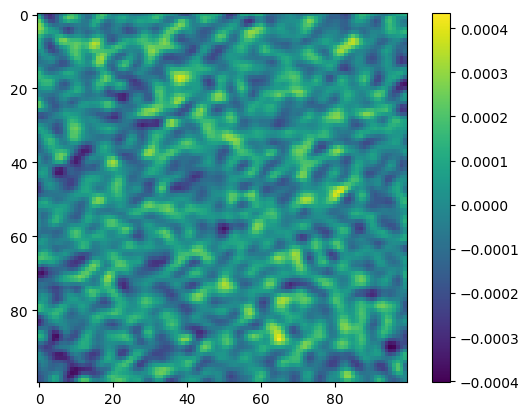

In [8]:
plt.imshow(mask, cmap = 'viridis')
plt.colorbar()
plt.show()

# While this is a good preliminary plot, I can do it more professional. 
- WCS (World Coordinate System) can transform Pixel Addresses (x,y) into Sky Addresses (Right Ascension and Declination).  --> Help from gemini
- labels
- Colorbar units
- align the data array with the WCS coordinate system so your "Up" is actually North and your "Left" is actually East. (using origin = 'lower')
---
# HOW WCS Math works: 

Your header contains the three ingredients needed for this translation:

    The Anchor (CRVAL and CRPIX): The header says pixel (8075,8075) is exactly at RA≈45.0∘,Dec≈87.07∘. This "pins" the map to a specific spot in the sky.

    The Scale (CDELT): It tells the computer how much "sky" is inside one pixel. In your file, moving one pixel is a tiny jump of 0.000416∘.

    The Projection (CTYPE): The sky is a sphere, but your screen is flat. You can't flatten a orange peel without stretching it. 'RA---SIN' tells the computer to use a Sinu-orthographic math formula to handle that stretching.

The transformation looks roughly like this (simplified):
Sky Position=Anchor Value+(Pixel Distance from Anchor×Pixel Scale)

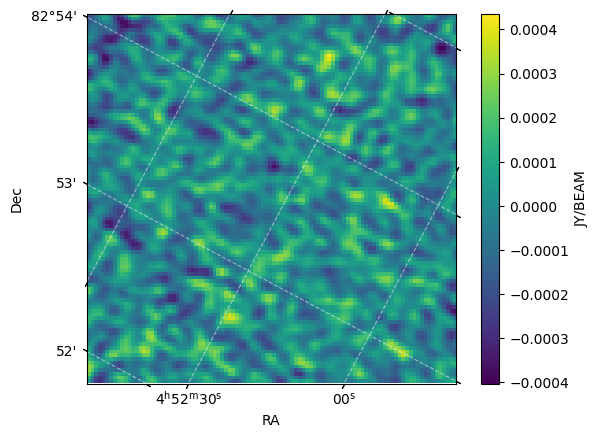

In [9]:
from astropy.wcs import WCS

# load the WCS information from the header
wcs = WCS(hdul[0].header)

# plotting with coordinates
ax = plt.subplot(projection=wcs) # ---> Don't use linear axes but rather calculate from 'wcs'. 
ax.coords.grid(color='white', linestyle='--', alpha=0.5) # visualize grid. 

plt.imshow(mask, origin='lower', cmap='viridis') 
plt.xlabel('RA')
plt.ylabel('Dec')
plt.colorbar(label=hdul[0].header['BUNIT'])  # Getting the units of Brightness. 
plt.show()

Let's now define a function that can plot everything with just the hdul, and desired pixels (as array?)

In [10]:
from matplotlib.colors import LogNorm
import os

def myplot(hdul, x_arr, y_arr, vmin=0, vmax=0.02): 
    dat = hdul[0].data # Could also do     hdul = fits.open('mosaic.fits')    but this is computationally expensive to do each time. 

    x_slice = slice(int(x_arr[0]), int(x_arr[1]))
    y_slice = slice(int(y_arr[0]), int(y_arr[1]))

    mask = dat[y_slice, x_slice] # OJO: y = row --> dat[0]      x = column ---> dat[1]
    
    #PREVIOUS: (incorrect!!)   mask = dat[arr1[0]:arr1[1], arr2[0]:arr2[1]]   # Get start and end pixel position for (x, y)

    wcs = WCS(hdul[0].header)

    # plotting with coordinates
    ax = plt.subplot(projection=wcs[y_slice, x_slice]) # ---> Don't use linear axes but rather calculate from 'wcs'.
                                # the y, x slice allows for the RA/Dec to shift with crop (GEMINI info)
    
    ax.coords.grid(color='white', linestyle='--', alpha=0.5) # visualize grid. 
    
    plt.imshow(mask, origin='lower', cmap='viridis', vmin=vmin, vmax=vmax)                # Could also do norm=LogNorm(vmin=0.001, vmax=0.1))
                                                    # vmin / vmax to account for high dynamic range 
                                                    # (set floor / max for brightness displayed)
    plt.xlabel('RA')
    plt.ylabel('Dec')

    center_x = (x_arr[0] + x_arr[1]) / 2.0
    center_y = (y_arr[0] + y_arr[1]) / 2.0
    
    coord_at_center = wcs.pixel_to_world(center_x, center_y) # GEMINI: --> Convert pixels back to a SkyCoord object
    
    plt.title(f"RA: {coord_at_center.ra.deg:.3f}°, Dec: {coord_at_center.dec.deg:.3f}°")
    plt.colorbar(label=hdul[0].header['BUNIT'])  # Getting the units of Brightness. 

    
    save_fig(coord_at_center)
    plt.show()


def save_fig(coord_obj, folder="plots_random", dpi=600): # ---> help from GEMINi
    """Handles directory creation and naming for astronomical plots."""
    
    # Create the folder if it doesn't exist
    if not os.path.exists(folder):
        os.makedirs(folder)

    # Format the filename using coordinates
    ra_val = coord_obj.ra.deg
    dec_val = coord_obj.dec.deg
    filename = f"RA_{ra_val:.3f}_Dec_{dec_val:.3f}.png"
    
    # Save the current active plot
    save_path = os.path.join(folder, filename)
    plt.savefig(save_path, dpi=dpi, bbox_inches='tight')
    print(f"Successfully saved to: {save_path}")
    
# e.g. 
#myplot(hdul, [2500, 3500], [2500, 3500])

Successfully saved to: plots_random/RA_35.625_Dec_86.319.png


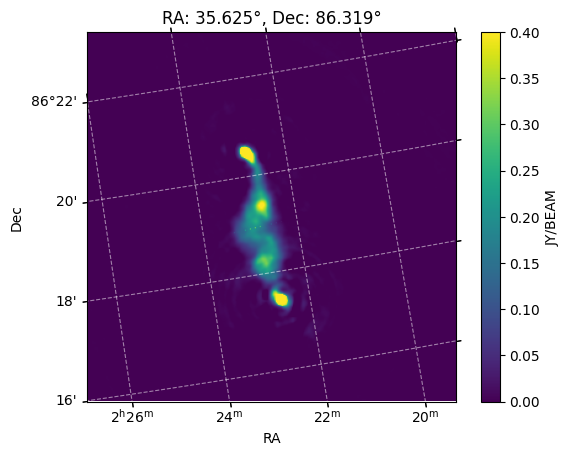

In [112]:

from astropy.coordinates import SkyCoord 
from astropy.wcs.utils import skycoord_to_pixel

'''
Plot 3C 61.1 (The "Classic" Radio Galaxy)
Use SkyCoord and skycoord_to_pixel to convert position in sky to pixel coordinates.  
'''
target_pos = SkyCoord(ra=35.625, dec=86.319, unit='deg', frame='icrs') # --> Help from gemini
 
# 2. Convert that Sky Position to Pixel Coordinates (x, y)
px, py = skycoord_to_pixel(target_pos, wcs)
myplot(hdul, [px-150, px+150], [py-150, py+150], vmin=0, vmax=0.4)

Successfully saved to: plots_random/RA_35.609_Dec_86.325.png


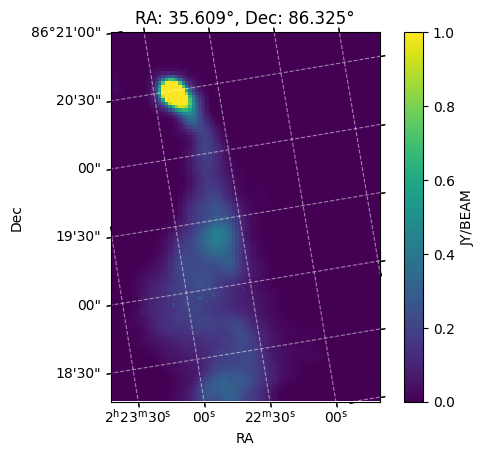

In [113]:
myplot(hdul, [px-40, px+40], [py-40, py+70], vmin=0, vmax=1) # ZOOMED IN PICTURE. 